disk_name   x_point   y_point  x_centre  y_centre  X_sky_arcsec  Y_sky_arcsec
  LkCa_15 -1.048382 -0.298355 -0.016844  0.020828     -1.031538     -0.319184
   SY_Cha -0.493551 -0.286909 -0.012655  0.028159     -0.480896     -0.315068
   AA_Tau -0.263165  0.199770 -0.005459  0.004827     -0.257706      0.194943
    J1615 -0.139084 -1.075395 -0.044317 -0.005884     -0.094767     -1.069511
    J1842 -0.233913  0.357650 -0.003165 -0.030689     -0.230748      0.388339


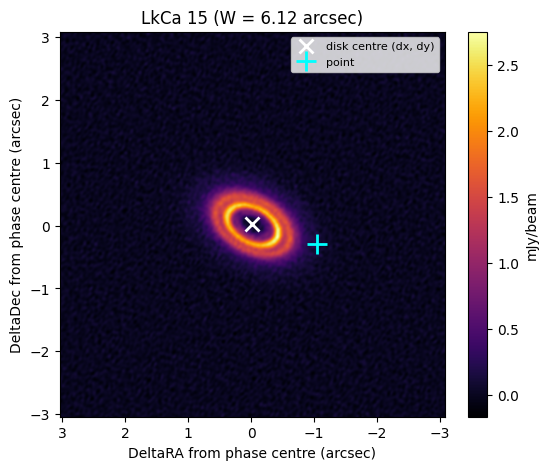

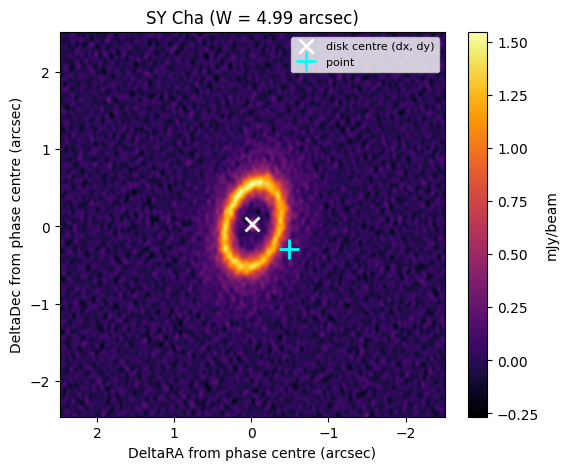

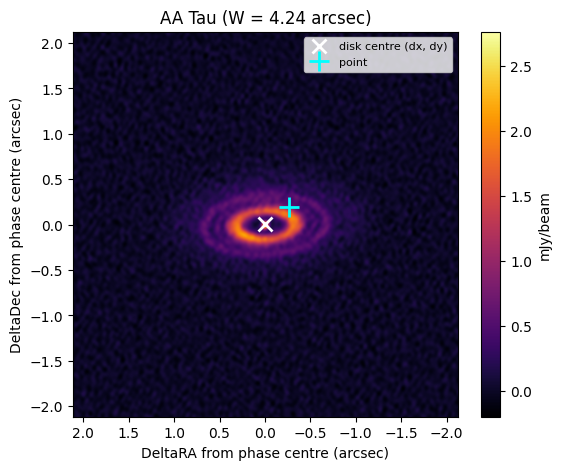

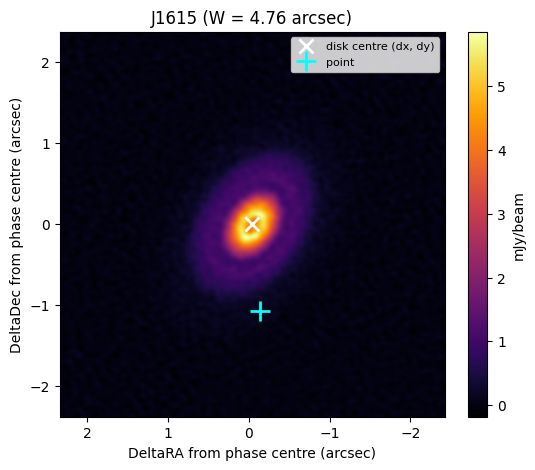

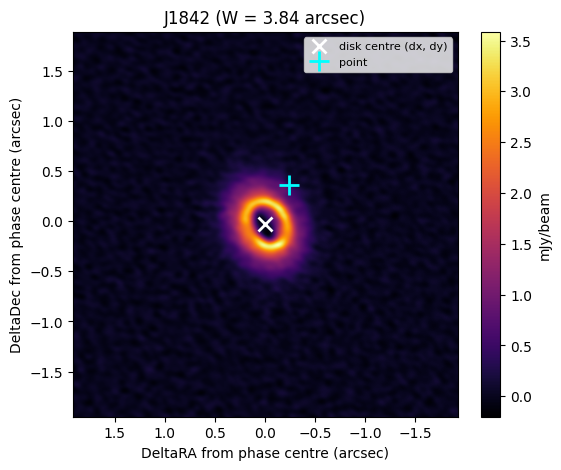

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import sys
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as diskdict

base = r"D:\exoALMA_disk_data"

# verified inputs: full panel width W (arcsec) and point position as a fraction (0-1) of the panel,
# (0,0) = lower-left, (1,1) = upper-right, panel centred on the disk centre
panel_width = {"LkCa_15": 6.12, "SY_Cha": 4.99, "AA_Tau": 4.24, "J1615": 4.76, "J1842": 3.84}
points = {
    "LkCa_15": (0.6685520361990951, 0.44784580498866217),
    "SY_Cha":  (0.5963718820861679, 0.4368600682593856),
    "AA_Tau":  (0.5607798165137615, 0.5459770114942528),
    "J1615":   (0.5199089874857793, 0.2753128555176337),
    "J1842":   (0.5600907029478458, 0.6011299435028249),
}

# every x/y below is a FITS offset from the phase centre (CRPIX), in arcsec:
#   x = DeltaRA  (positive = east = LEFT on the image)
#   y = DeltaDec (positive = north = up)
# disk centre in these coords = (dx, dy) from diskdictionary_eqC1
rows = []
for name, W in panel_width.items():
    d = diskdict.disk[name]
    xf, yf = points[name]
    x_centre, y_centre = d["dx"], d["dy"]
    x_point = x_centre + W / 2 - xf * W   # panel fraction increases to the right (west), DeltaRA increases to the east
    y_point = y_centre + yf * W - W / 2
    rows.append(dict(disk_name=name, x_point=x_point, y_point=y_point, x_centre=x_centre, y_centre=y_centre,
                     X_sky_arcsec=x_point - x_centre, Y_sky_arcsec=y_point - y_centre))

print(pd.DataFrame(rows).to_string(index=False))

for row in rows:
    name, W = row["disk_name"], panel_width[row["disk_name"]]
    hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust-0.5.image.fits")
    img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
    hd = hdu[0].header
    RAo  = 3600 * hd["CDELT1"] * (np.arange(hd["NAXIS1"]) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(hd["NAXIS2"]) - (hd["CRPIX2"] - 1))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(img, origin="lower", cmap="inferno", extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])
    fig.colorbar(im, ax=ax, fraction=0.046, label="mJy/beam")
    ax.plot(row["x_centre"], row["y_centre"], marker="x", color="white", markersize=10, markeredgewidth=2, ls="", label="disk centre (dx, dy)")
    ax.plot(row["x_point"], row["y_point"], marker="+", color="cyan", markersize=15, markeredgewidth=2, ls="", label="point")
    ax.set_title(f"{name.replace('_', ' ')} (W = {W} arcsec)")
    ax.set_xlabel("DeltaRA from phase centre (arcsec)")
    ax.set_ylabel("DeltaDec from phase centre (arcsec)")
    ax.set_xlim(row["x_centre"] + W / 2, row["x_centre"] - W / 2)
    ax.set_ylim(row["y_centre"] - W / 2, row["y_centre"] + W / 2)
    ax.legend(fontsize=8, loc="upper right")
    plt.show()

In [2]:
geo = pd.DataFrame(rows)
geo["PA_deg"] = [diskdict.disk[n]["PA"] for n in geo.disk_name]
geo["inclination_deg"] = [diskdict.disk[n]["incl"] for n in geo.disk_name]
PA, inc = np.radians(geo.PA_deg), np.radians(geo.inclination_deg)
X, Y = geo.X_sky_arcsec, geo.Y_sky_arcsec

geo["x_maj_arcsec"] = X * np.sin(PA) + Y * np.cos(PA)
geo["y_min_arcsec"] = -X * np.cos(PA) + Y * np.sin(PA)
geo["x_disk_arcsec"] = geo.x_maj_arcsec
geo["y_disk_arcsec"] = geo.y_min_arcsec / np.cos(inc)
geo["r_arcsec"] = np.hypot(geo.x_disk_arcsec, geo.y_disk_arcsec)
geo["distance_pc"] = [diskdict.disk[n]["distance"] for n in geo.disk_name]
geo["r_AU"] = geo.r_arcsec * geo.distance_pc
# theta = 0: along the major axis in the direction of PA (east of north).
# theta increases from there toward the +y_min axis, i.e. toward PA - 90 deg
# (clockwise on the sky as displayed, east left / north up). Range (-180, 180] from arctan2, no wrapping.
geo["theta_deg"] = np.degrees(np.arctan2(geo.y_disk_arcsec, geo.x_disk_arcsec))

print(geo.to_string(index=False))
geo.to_csv("disk_plane_coordinates.txt", sep="\t", index=False)

disk_name   x_point   y_point  x_centre  y_centre  X_sky_arcsec  Y_sky_arcsec     PA_deg  inclination_deg  x_maj_arcsec  y_min_arcsec  x_disk_arcsec  y_disk_arcsec  r_arcsec  distance_pc       r_AU  theta_deg
  LkCa_15 -1.048382 -0.298355 -0.016844  0.020828     -1.031538     -0.319184  61.572325        50.594940     -1.059101      0.210367      -1.059101       0.331391  1.109737          156 173.118945 162.625172
   SY_Cha -0.493551 -0.286909 -0.012655  0.028159     -0.480896     -0.315068 165.765113        51.646422      0.187143     -0.543605       0.187143      -0.876057  0.895823          182 163.039831 -77.941726
   AA_Tau -0.263165  0.199770 -0.005459  0.004827     -0.257706      0.194943  93.770798        58.535312     -0.269969      0.177572      -0.269969       0.340195  0.434299          135  58.630357 128.434544
    J1615 -0.139084 -1.075395 -0.044317 -0.005884     -0.094767     -1.069511 146.143279        47.097757      0.835361     -0.674541       0.835361      -0.990880 

In [3]:
# Table 2 of the phantom + mcfost paper: r_planet (au)
r_planet_paper = {"AA_Tau": 80, "J1615": 310, "J1842": 105, "LkCa_15": 240, "SY_Cha": 140}

cmp = geo[["disk_name", "r_AU", "theta_deg"]].copy()
cmp["r_planet_paper_AU"] = [r_planet_paper[n] for n in cmp.disk_name]
cmp["r_AU / r_planet"] = cmp.r_AU / cmp.r_planet_paper_AU
print(cmp.to_string(index=False))

disk_name       r_AU  theta_deg  r_planet_paper_AU  r_AU / r_planet
  LkCa_15 173.118945 162.625172                240         0.721329
   SY_Cha 163.039831 -77.941726                140         1.164570
   AA_Tau  58.630357 128.434544                 80         0.732879
    J1615 202.179353 -49.867448                310         0.652191
    J1842  82.677741  63.352335                105         0.787407


In [4]:
cmp["W_current_arcsec"] = [panel_width[n] for n in cmp.disk_name]
cmp["W_required_arcsec"] = cmp.W_current_arcsec * cmp.r_planet_paper_AU / cmp.r_AU
print(cmp[["disk_name", "W_current_arcsec", "r_AU", "r_planet_paper_AU", "W_required_arcsec"]].to_string(index=False))

disk_name  W_current_arcsec       r_AU  r_planet_paper_AU  W_required_arcsec
  LkCa_15              6.12 173.118945                240           8.484340
   SY_Cha              4.99 163.039831                140           4.284843
   AA_Tau              4.24  58.630357                 80           5.785399
    J1615              4.76 202.179353                310           7.298470
    J1842              3.84  82.677741                105           4.876766


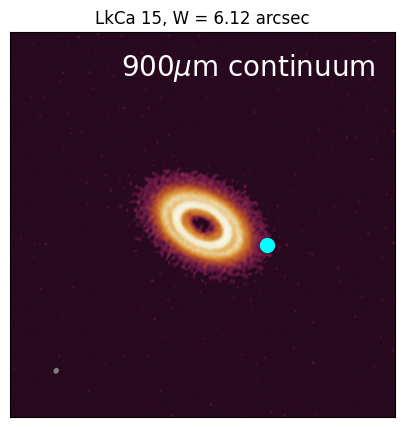

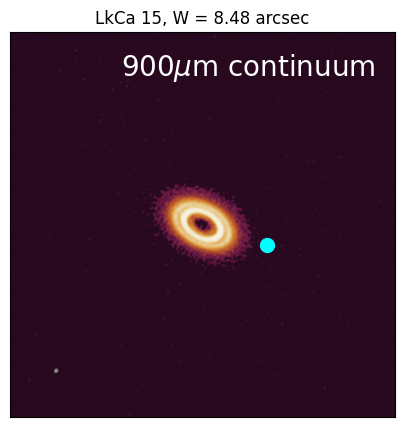

In [5]:
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

# LkCa 15 in the paper's panel style, for the current (6.12") and required (8.48") widths.
# the point sits at the same panel fraction (xf, yf) in both, so its arcsec position scales with W
name = "LkCa_15"
d = diskdict.disk[name]
xf, yf = points[name]
hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust-0.5.image.fits")
img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
hd = hdu[0].header
RAo  = 3600 * hd["CDELT1"] * (np.arange(hd["NAXIS1"]) - (hd["CRPIX1"] - 1)) - d["dx"]
DECo = 3600 * hd["CDELT2"] * (np.arange(hd["NAXIS2"]) - (hd["CRPIX2"] - 1)) - d["dy"]
bmaj, bmin, bpa = 3600 * hd["BMAJ"], 3600 * hd["BMIN"], hd["BPA"]

# paper-like colours: maroon background -> magenta rim -> orange -> cream ring; sqrt stretch, noise below 3 sigma clipped
cmap = LinearSegmentedColormap.from_list("paper", ["#28091f", "#6e1a45", "#b8502a", "#dc9a3c", "#f0e6c0", "#f7f7ee"])
rms = np.std(img[:200, :200])
norm = PowerNorm(0.5, vmin=3 * rms, vmax=img.max(), clip=True)

for W in [6.12, 8.48]:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img, origin="lower", cmap=cmap, norm=norm, extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])
    ax.plot(W * (0.5 - xf), W * (yf - 0.5), "o", color="cyan", markersize=10)
    ax.add_patch(Ellipse((0.38 * W, -0.38 * W), bmin, bmaj, angle=-bpa, color="grey"))
    ax.text(0.95, 0.95, "900$\\mu$m continuum", color="white", fontsize=20, ha="right", va="top", transform=ax.transAxes)
    ax.set_xlim(W / 2, -W / 2)
    ax.set_ylim(-W / 2, W / 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"LkCa 15, W = {W} arcsec")
    plt.show()